In [24]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import precision_score, f1_score, recall_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

In [25]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [28]:
!ls "/content/drive/MyDrive/MaestDataMining/Especializacion/Laburo_Final_Especializacion/Datos y Script"

Código-EFinal-G2-GonzálezGarello-Tomás.ipynb  Datos_Medias.csv


In [29]:
ruta = "/content/drive/MyDrive/MaestDataMining/Especializacion/Laburo_Final_Especializacion/Datos y Script/Datos_Medias.csv"
df = pd.read_csv(ruta)
df.head()

,ID,Diagnosis,Mean_Radius,Mean_Texture,Mean_Perimeter,Mean_Area,Mean_Smoothness,Mean_Compactness,Mean_Concavity,Mean_Concave_Points,Mean_Symmetry,Mean_Fractal_Dimension
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883


In [ ]:
df['Diagnosis'].value_counts()

,count
Diagnosis,
B,357
M,212


In [ ]:
# 1. Separar variables y target
X = df.drop(columns=["Diagnosis", "ID"])
y = df["Diagnosis"]

# 2. Separar una base de validación externa (20% es razonable)
X_train_full, X_val, y_train_full, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 3. Escalar SOLO las variables para SVM (mantener escalado separado)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_full)
X_val_scaled = scaler.transform(X_val)

In [ ]:
X.head()

,Mean_Radius,Mean_Texture,Mean_Perimeter,Mean_Area,Mean_Smoothness,Mean_Compactness,Mean_Concavity,Mean_Concave_Points,Mean_Symmetry,Mean_Fractal_Dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883


### Regresión Logística

In [ ]:
# Variables a usar
X_cv = X_train_full.values
y_cv = y_train_full.values

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

thresholds = np.linspace(0, 1, 101)  # 0.00, 0.01, ..., 1.00

f1_scores_folds = []
precision_scores_folds = []
recall_scores_folds = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X_cv, y_cv), 1):
    X_train, X_test = X_cv[train_idx], X_cv[test_idx]
    y_train, y_test = y_cv[train_idx], y_cv[test_idx]

    # Modelo
    model = LogisticRegression(penalty=None, solver='lbfgs', max_iter=1000)
    model.fit(X_train, y_train)

    # Probabilidades predichas para la clase positiva ('M')
    proba_pos = model.predict_proba(X_test)[:, 1]

    f1_scores = []
    precision_scores = []
    recall_scores = []

    for thresh in thresholds:
        y_pred = (proba_pos >= thresh).astype(int)
        y_test_bin = (y_test == 'M').astype(int)

        f1 = f1_score(y_test_bin, y_pred, zero_division=0)
        precision = precision_score(y_test_bin, y_pred, zero_division=0)
        recall = recall_score(y_test_bin, y_pred, zero_division=0)

        f1_scores.append(f1)
        precision_scores.append(precision)
        recall_scores.append(recall)

    f1_scores_folds.append(f1_scores)
    precision_scores_folds.append(precision_scores)
    recall_scores_folds.append(recall_scores)



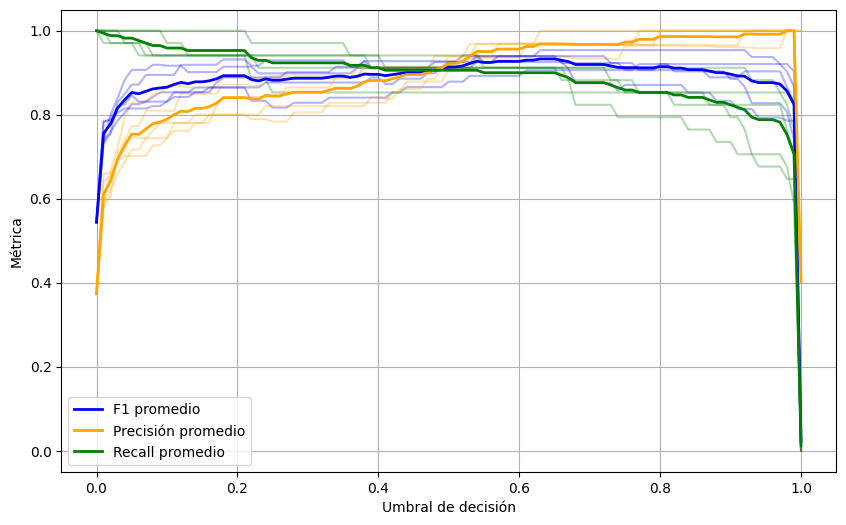

In [ ]:
# Convertir listas a arrays para facilitar cálculo de promedio
f1_scores_folds = np.array(f1_scores_folds)
precision_scores_folds = np.array(precision_scores_folds)
recall_scores_folds = np.array(recall_scores_folds)

# Promedio y desviación estándar entre folds
f1_mean = f1_scores_folds.mean(axis=0)
f1_std = f1_scores_folds.std(axis=0)
precision_mean = precision_scores_folds.mean(axis=0)
precision_std = precision_scores_folds.std(axis=0)
recall_mean = recall_scores_folds.mean(axis=0)
recall_std = recall_scores_folds.std(axis=0)

# Graficar
plt.figure(figsize=(10,6))

# Curvas fold individuales (transparencia)
for i in range(5):
    plt.plot(thresholds, f1_scores_folds[i], color='blue', alpha=0.3)
    plt.plot(thresholds, precision_scores_folds[i], color='orange', alpha=0.3)
    plt.plot(thresholds, recall_scores_folds[i], color='green', alpha=0.3)

# Curvas promedio (más gruesas)
plt.plot(thresholds, f1_mean, color='blue', linewidth=2, label='F1 promedio')
plt.plot(thresholds, precision_mean, color='orange', linewidth=2, label='Precisión promedio')
plt.plot(thresholds, recall_mean, color='green', linewidth=2, label='Recall promedio')

plt.xlabel('Umbral de decisión')
plt.ylabel('Métrica')
plt.title('')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Encontrar índice del umbral con el F1 promedio máximo
best_idx_rl = np.argmax(f1_mean)
best_threshold_rl = thresholds[best_idx_rl]

# Guardar umbral óptimo en un diccionario para usar luego
optimal_thresholds = {}
optimal_thresholds['logistic_regression'] = best_threshold_rl

# Imprimir resultado
print(f"Umbral óptimo para regresión logística (F1 promedio máximo): {best_threshold_rl:.2f}")

Umbral óptimo para regresión logística (F1 promedio máximo): 0.63


### Random Forest

In [ ]:
# Variables a usar
X_cv = X_train_full.values
y_cv = y_train_full.values

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

thresholds = np.linspace(0, 1, 101)

f1_scores_folds_rf = []
precision_scores_folds_rf = []
recall_scores_folds_rf = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X_cv, y_cv), 1):
    X_train, X_test = X_cv[train_idx], X_cv[test_idx]
    y_train, y_test = y_cv[train_idx], y_cv[test_idx]

    # Modelo RF
    model_rf = RandomForestClassifier(random_state=42)
    model_rf.fit(X_train, y_train)

    # Probabilidades para clase positiva ('M')
    proba_pos_rf = model_rf.predict_proba(X_test)[:, 1]

    f1_scores = []
    precision_scores = []
    recall_scores = []

    for thresh in thresholds:
        y_pred = (proba_pos_rf >= thresh).astype(int)
        y_test_bin = (y_test == 'M').astype(int)

        f1 = f1_score(y_test_bin, y_pred)
        precision = precision_score(y_test_bin, y_pred, zero_division=0)
        recall = recall_score(y_test_bin, y_pred, zero_division=0)

        f1_scores.append(f1)
        precision_scores.append(precision)
        recall_scores.append(recall)

    f1_scores_folds_rf.append(f1_scores)
    precision_scores_folds_rf.append(precision_scores)
    recall_scores_folds_rf.append(recall_scores)


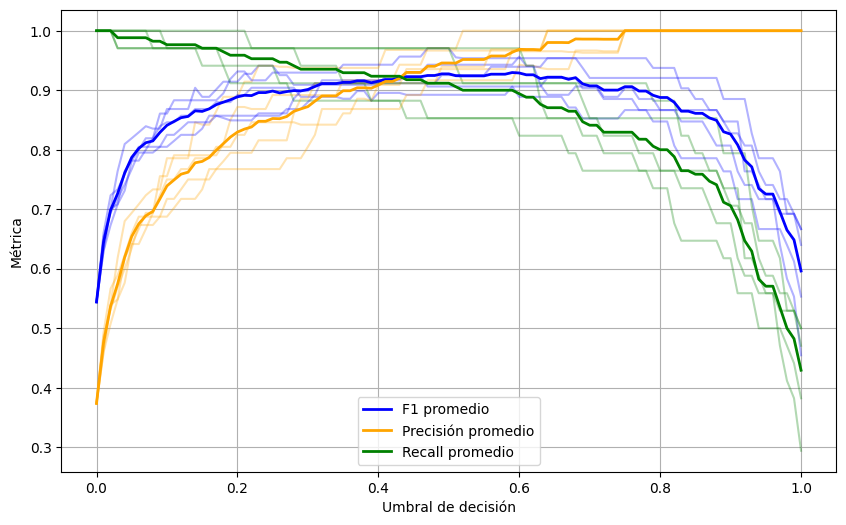

In [ ]:
# Convertir a arrays numpy
f1_scores_folds_rf = np.array(f1_scores_folds_rf)
precision_scores_folds_rf = np.array(precision_scores_folds_rf)
recall_scores_folds_rf = np.array(recall_scores_folds_rf)

# Promedio y desviación estándar
f1_mean_rf = f1_scores_folds_rf.mean(axis=0)
f1_std_rf = f1_scores_folds_rf.std(axis=0)

precision_mean_rf = precision_scores_folds_rf.mean(axis=0)
precision_std_rf = precision_scores_folds_rf.std(axis=0)

recall_mean_rf = recall_scores_folds_rf.mean(axis=0)
recall_std_rf = recall_scores_folds_rf.std(axis=0)

# Graficar
plt.figure(figsize=(10,6))

# Curvas fold individuales (transparencia)
for i in range(5):
    plt.plot(thresholds, f1_scores_folds_rf[i], color='blue', alpha=0.3)
    plt.plot(thresholds, precision_scores_folds_rf[i], color='orange', alpha=0.3)
    plt.plot(thresholds, recall_scores_folds_rf[i], color='green', alpha=0.3)

# Curvas promedio (más gruesas)
plt.plot(thresholds, f1_mean_rf, color='blue', linewidth=2, label='F1 promedio')
plt.plot(thresholds, precision_mean_rf, color='orange', linewidth=2, label='Precisión promedio')
plt.plot(thresholds, recall_mean_rf, color='green', linewidth=2, label='Recall promedio')

plt.xlabel('Umbral de decisión')
plt.ylabel('Métrica')
plt.title('')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Umbral óptimo según F1 promedio
best_idx_rf = np.argmax(f1_mean_rf)
best_threshold_rf = thresholds[best_idx_rf]

print(f"Umbral óptimo para Random Forest (F1 promedio máximo): {best_threshold_rf:.2f}")

# Guardar
optimal_thresholds['random_forest'] = best_threshold_rf

Umbral óptimo para Random Forest (F1 promedio máximo): 0.59


### Boosting

In [ ]:
f1_scores_folds_gb = []
precision_scores_folds_gb = []
recall_scores_folds_gb = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X_cv, y_cv), 1):
    X_train, X_test = X_cv[train_idx], X_cv[test_idx]
    y_train, y_test = y_cv[train_idx], y_cv[test_idx]

    # Modelo Boosting
    model_gb = GradientBoostingClassifier(random_state=42)
    model_gb.fit(X_train, y_train)

    # Probabilidades para clase positiva ('M')
    proba_pos_gb = model_gb.predict_proba(X_test)[:, 1]

    f1_scores = []
    precision_scores = []
    recall_scores = []

    for thresh in thresholds:
        y_pred = (proba_pos_gb >= thresh).astype(int)
        y_test_bin = (y_test == 'M').astype(int)

        f1 = f1_score(y_test_bin, y_pred)
        precision = precision_score(y_test_bin, y_pred, zero_division=0)
        recall = recall_score(y_test_bin, y_pred, zero_division=0)

        f1_scores.append(f1)
        precision_scores.append(precision)
        recall_scores.append(recall)

    f1_scores_folds_gb.append(f1_scores)
    precision_scores_folds_gb.append(precision_scores)
    recall_scores_folds_gb.append(recall_scores)

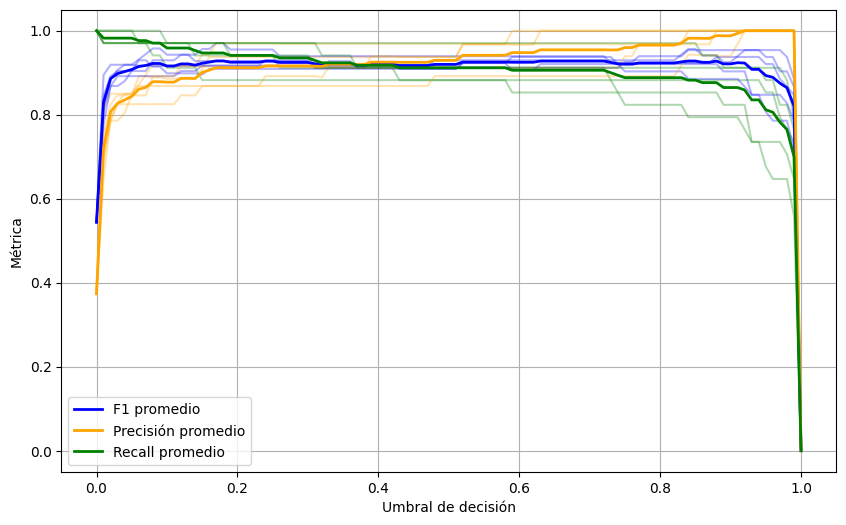

In [ ]:
# Arrays numpy
f1_scores_folds_gb = np.array(f1_scores_folds_gb)
precision_scores_folds_gb = np.array(precision_scores_folds_gb)
recall_scores_folds_gb = np.array(recall_scores_folds_gb)

# Promedios
f1_mean_gb = f1_scores_folds_gb.mean(axis=0)
precision_mean_gb = precision_scores_folds_gb.mean(axis=0)
recall_mean_gb = recall_scores_folds_gb.mean(axis=0)

# Graficar
plt.figure(figsize=(10,6))

for i in range(5):
    plt.plot(thresholds, f1_scores_folds_gb[i], color='blue', alpha=0.3)
    plt.plot(thresholds, precision_scores_folds_gb[i], color='orange', alpha=0.3)
    plt.plot(thresholds, recall_scores_folds_gb[i], color='green', alpha=0.3)

plt.plot(thresholds, f1_mean_gb, color='blue', linewidth=2, label='F1 promedio')
plt.plot(thresholds, precision_mean_gb, color='orange', linewidth=2, label='Precisión promedio')
plt.plot(thresholds, recall_mean_gb, color='green', linewidth=2, label='Recall promedio')

plt.xlabel('Umbral de decisión')
plt.ylabel('Métrica')
plt.title('')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
best_idx_gb = np.argmax(f1_mean_gb)
best_threshold_gb = thresholds[best_idx_gb]

print(f"Umbral óptimo para Gradient Boosting (F1 promedio máximo): {best_threshold_gb:.2f}")

optimal_thresholds['boosting'] = best_threshold_gb

Umbral óptimo para Gradient Boosting (F1 promedio máximo): 0.17


### SVM

In [ ]:
# Variables seleccionadas tras análisis de colinealidad para SVM
X_svm = X_train_full[["Mean_Texture", "Mean_Compactness", "Mean_Symmetry", "Mean_Fractal_Dimension"]].copy()
y_svm = (y_train_full == "M").astype(int)  # Clase positiva = 'M'

# Estandarizar las variables (muy importante para SVM)
scaler = StandardScaler()
X_svm_scaled = scaler.fit_transform(X_svm)

# Configurar validación cruzada estratificada
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
thresholds = np.linspace(0, 1, 101)  # Umbrales de 0.00 a 1.00

# Inicializar listas para almacenar métricas de cada fold
f1_scores_folds = []
precision_scores_folds = []
recall_scores_folds = []

# Loop sobre folds
for train_idx, test_idx in skf.split(X_svm_scaled, y_svm):
    X_train, X_test = X_svm_scaled[train_idx], X_svm_scaled[test_idx]
    y_train, y_test = y_svm.iloc[train_idx], y_svm.iloc[test_idx]

    # Entrenar SVM con probabilidad activada
    model = SVC(kernel='rbf', probability=True, random_state=42)
    model.fit(X_train, y_train)

    # Obtener probabilidades de clase positiva
    proba_pos = model.predict_proba(X_test)[:, 1]

    # Calcular métricas para cada umbral
    f1_scores = []
    precision_scores = []
    recall_scores = []

    for thresh in thresholds:
        y_pred = (proba_pos >= thresh).astype(int)
        f1_scores.append(f1_score(y_test, y_pred))
        precision_scores.append(precision_score(y_test, y_pred))
        recall_scores.append(recall_score(y_test, y_pred))

    f1_scores_folds.append(f1_scores)
    precision_scores_folds.append(precision_scores)
    recall_scores_folds.append(recall_scores)

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.p

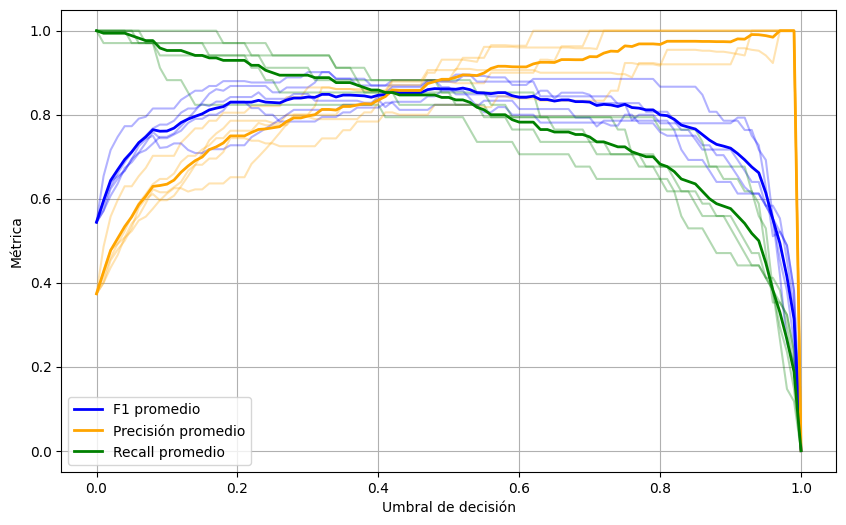

In [ ]:
# Convertir listas a numpy arrays para promediar
f1_scores_folds = np.array(f1_scores_folds)
precision_scores_folds = np.array(precision_scores_folds)
recall_scores_folds = np.array(recall_scores_folds)

# Promedio de métricas entre folds
f1_mean = f1_scores_folds.mean(axis=0)
precision_mean = precision_scores_folds.mean(axis=0)
recall_mean = recall_scores_folds.mean(axis=0)

# Graficar curvas
plt.figure(figsize=(10, 6))
for i in range(5):
    plt.plot(thresholds, f1_scores_folds[i], color='blue', alpha=0.3)
    plt.plot(thresholds, precision_scores_folds[i], color='orange', alpha=0.3)
    plt.plot(thresholds, recall_scores_folds[i], color='green', alpha=0.3)

plt.plot(thresholds, f1_mean, color='blue', linewidth=2, label='F1 promedio')
plt.plot(thresholds, precision_mean, color='orange', linewidth=2, label='Precisión promedio')
plt.plot(thresholds, recall_mean, color='green', linewidth=2, label='Recall promedio')

plt.xlabel('Umbral de decisión')
plt.ylabel('Métrica')
plt.title('')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Calcular índice y umbral óptimo para SVM basado en máximo F1 promedio
best_idx_svm = np.argmax(f1_mean)
best_threshold_svm = thresholds[best_idx_svm]

# Guardar en el diccionario de umbrales óptimos
optimal_thresholds['svm'] = best_threshold_svm

# Imprimir para verificar
print(f"Umbral óptimo (SVM) según F1 promedio: {best_threshold_svm:.2f}")

Umbral óptimo (SVM) según F1 promedio: 0.52


In [ ]:
# Imprimir para verificar
print("Umbrales óptimos:")
for k,v in optimal_thresholds.items():
    print(f"{k}: {v:.2f}")

Umbrales óptimos:
logistic_regression: 0.63
svm: 0.52
boosting: 0.17
random_forest: 0.59


In [ ]:
# ¿Cómo es la base de validación?
# Conteo de cada clase en la base de validación
val_class_counts = y_val.value_counts()

print("Distribución de clases en la base de validación:")
print(val_class_counts)

# También podés mostrar porcentajes
val_class_percent = y_val.value_counts(normalize=True) * 100
print("\nPorcentaje de cada clase en la base de validación:")
print(val_class_percent.round(2))

Distribución de clases en la base de validación:
Diagnosis
B    72
M    42
Name: count, dtype: int64

Porcentaje de cada clase en la base de validación:
Diagnosis
B    63.16
M    36.84
Name: proportion, dtype: float64


In [ ]:
# Variables completas (sin escalar) para RL, RF, Boosting
X_train_full_np = X_train_full.values
X_val_np = X_val.values

# Variables para SVM (ya seleccionadas y escaladas)
X_train_svm = X_svm.values
X_val_svm = X_val[["Mean_Texture", "Mean_Compactness", "Mean_Symmetry", "Mean_Fractal_Dimension"]].values

# Escalado para SVM (suponiendo que ya hiciste esto)
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train_svm)
# X_val_scaled = scaler.transform(X_val_svm)

# Etiquetas binarias para validación
y_val_bin = (y_val == 'M').astype(int)
y_train_bin = (y_train_full == 'M').astype(int)

# Umbrales óptimos que ya guardaste (solo ejemplos, reemplaza con tus valores)
threshold_rl = optimal_thresholds['logistic_regression']
threshold_rf = optimal_thresholds['random_forest']
threshold_boost = optimal_thresholds['boosting']
threshold_svm = optimal_thresholds['svm']

def evaluar_modelo(model, X_train, y_train, X_val, y_val_bin, threshold):
    model.fit(X_train, y_train)
    proba_val = model.predict_proba(X_val)[:, 1]
    y_pred_val = (proba_val >= threshold).astype(int)
    f1 = f1_score(y_val_bin, y_pred_val, zero_division=0)
    precision = precision_score(y_val_bin, y_pred_val, zero_division=0)
    recall = recall_score(y_val_bin, y_pred_val, zero_division=0)
    return f1, precision, recall

# Modelos (recuerda SVM con probabilidad=True)
model_rl = LogisticRegression(penalty=None, solver='lbfgs', max_iter=1000)
model_rf = RandomForestClassifier(random_state=42)
model_boost = GradientBoostingClassifier(random_state=42)
model_svm = SVC(probability=True, random_state=42)

# Evaluar
results = {}

results['LogisticRegression'] = evaluar_modelo(model_rl, X_train_full_np, y_train_bin, X_val_np, y_val_bin, threshold_rl)
results['RandomForest'] = evaluar_modelo(model_rf, X_train_full_np, y_train_bin, X_val_np, y_val_bin, threshold_rf)
results['Boosting'] = evaluar_modelo(model_boost, X_train_full_np, y_train_bin, X_val_np, y_val_bin, threshold_boost)
results['SVM'] = evaluar_modelo(model_svm, X_train_scaled, y_train_bin, X_val_scaled, y_val_bin, threshold_svm)

# DataFrame resumen
df_results = pd.DataFrame(results, index=['F1', 'Precision', 'Recall']).T.reset_index()
df_results.rename(columns={'index': 'Modelo'}, inplace=True)



In [ ]:
print(df_results.round(3))

               Modelo     F1  Precision  Recall
0  LogisticRegression  0.905      0.905   0.905
1        RandomForest  0.900      0.947   0.857
2            Boosting  0.930      0.909   0.952
3                 SVM  0.951      0.975   0.929
